In [51]:
import pandas as pd  
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns
import random 

In [52]:
df = pd.read_csv(r"C:\Users\rohan\Electricity Demand Prediction Machine Learning Model\Electricity+Demand+Dataset.csv")
df.head()

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [54]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\766710655.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [56]:
df =df.set_index('Timestamp')

In [57]:
df

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [58]:
df[['Temperature', 'Humidity', 'Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


DATA CLEANING


In [59]:
#to check is thhere any null value in the dataset
df.isnull().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [60]:
#to show the records of null value present in dataset  
df[df.isnull().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [61]:
# showing the  data which has all null value  
df[df.isnull().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# we will drop all values which contains null value
df =df.dropna(how='all')

In [63]:
df


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [64]:
df.isnull().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [65]:
#chhecking any null value missed or not
df[df.isnull().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [66]:
df.shape

(43844, 8)

Backward Fill -bfill
Forward Fill -ffill

In [67]:
df[['hour','dayofweek','month','year','dayofyear']]= df[['hour','dayofweek','month','year','dayofyear']].ffill() 

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\3352106242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['hour','dayofweek','month','year','dayofyear']]= df[['hour','dayofweek','month','year','dayofyear']].ffill()


In [68]:
df[['Temperature', 'Humidity', 'Demand']]=df[['Temperature', 'Humidity', 'Demand']].bfill()

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\3471577007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Temperature', 'Humidity', 'Demand']]=df[['Temperature', 'Humidity', 'Demand']].bfill()


In [69]:
df['Demand']=df['Demand'].interpolate(method='time')

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\823444295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Demand']=df['Demand'].interpolate(method='time')


In [70]:
df.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [71]:
#shhape of dataframe  
df.shape 

(43844, 8)

In [72]:
#create a 'quarter' column in the dataset
df.insert(5,'quarter',df.index.quarter)

In [73]:
df.head()

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006


In [74]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [75]:
df[['hour','dayofweek','month','year','dayofyear']]= df[['hour','dayofweek','month','year','dayofyear']].astype(int) 

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\1594254696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['hour','dayofweek','month','year','dayofyear']]= df[['hour','dayofweek','month','year','dayofyear']].astype(int)


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int64  
 1   dayofweek    43844 non-null  int64  
 2   month        43844 non-null  int64  
 3   year         43844 non-null  int64  
 4   dayofyear    43844 non-null  int64  
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(3), int32(1), int64(5)
memory usage: 3.2 MB


In [77]:
#create a 'weekoftheyearr' column in the dataset
df.insert(5,'weekoftheyear',df.index.isocalendar().week.astype(int))

In [78]:
df.tail()

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957
2024-12-31,22,1,12,2024,366,1,4,3.000000,51.998107,3353.241682
2024-12-31,23,1,12,2024,366,1,4,6.037472,59.931925,3219.023339


In [79]:
#created a new column to check weakands 0-monday to 6- sunday 
df.insert(7,'is_weekends',df.index.dayofweek.isin([5,6]).astype(int))

In [80]:
df.head()

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006


In [81]:
df[df['is_weekends']==0]

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [82]:
#importing public holiday package 
import holidays

In [83]:
df['Holidays'] = holidays.IN(years=df.year)

C:\Users\rohan\AppData\Local\Temp\ipykernel_18772\158049035.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Holidays'] = holidays.IN(years=df.year)


In [84]:
df

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Holidays
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,NaN
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,NaN
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,NaN


In [85]:
df.Holidays.value_counts()

Holidays
Republic Day          120
Maha Shivaratri       120
Mahavir Jayanti       120
Good Friday           120
Buddha Purnima        120
Id-ul-Fitr            120
Bakrid                120
Janmashtami           120
Independence Day      120
Muharram              120
Gandhi Jayanti        120
Dussehra              120
Milad-un-Nabi         120
Diwali                120
Guru Nanak Jayanti    120
Christmas             120
Name: count, dtype: int64

In [86]:
df =df.drop('Holidays',axis=1)

In [87]:
df

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [88]:
#lagged  - these are the past value  of the  time series data
#use -past value are the stron prediction

In [89]:
df['Demand_lagged_24hr'] = df['Demand'].shift(24)

In [90]:
df['Demand_lagged_168hr'] =df['Demand'].shift(168)# 24x7 =168hrs for weekly  shift

In [91]:
df


,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Demand_lagged_24hr,Demand_lagged_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014


In [92]:
df.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Demand_lagged_24hr,Demand_lagged_168hr
Timestamp,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [93]:
#rolling mean  & rolling std
df['Demand_rolling_mean_24hr'] = df['Demand'].rolling(window=24).mean()

In [94]:
df['Demand_rolling_std_24hr'] = df['Demand'].rolling(window=24).std()

In [95]:
df

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Demand_lagged_24hr,Demand_lagged_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


In [96]:
#drop all NULL rows 
df =df.dropna()
df

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Demand_lagged_24hr,Demand_lagged_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


<Figure size 1000x600 with 0 Axes>

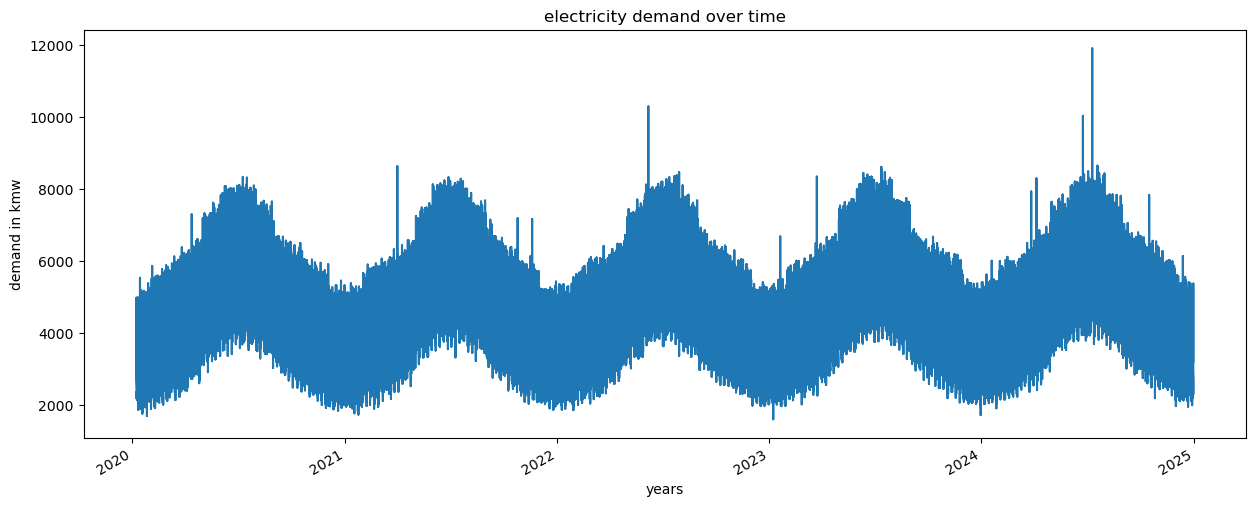

In [97]:
df['Demand'].plot(figsize=(15,6), title="electricity demand over time")
plt.xlabel("years")
plt.ylabel("demand in kmw")
plt.show()

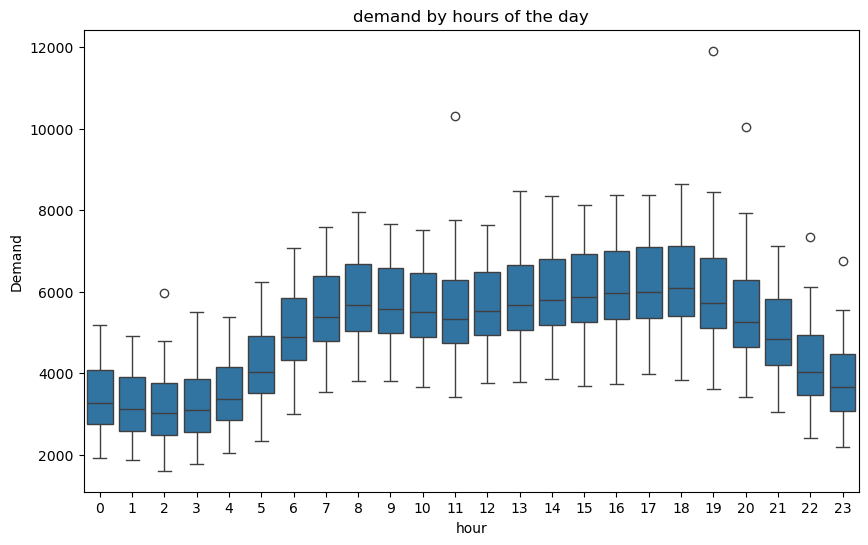

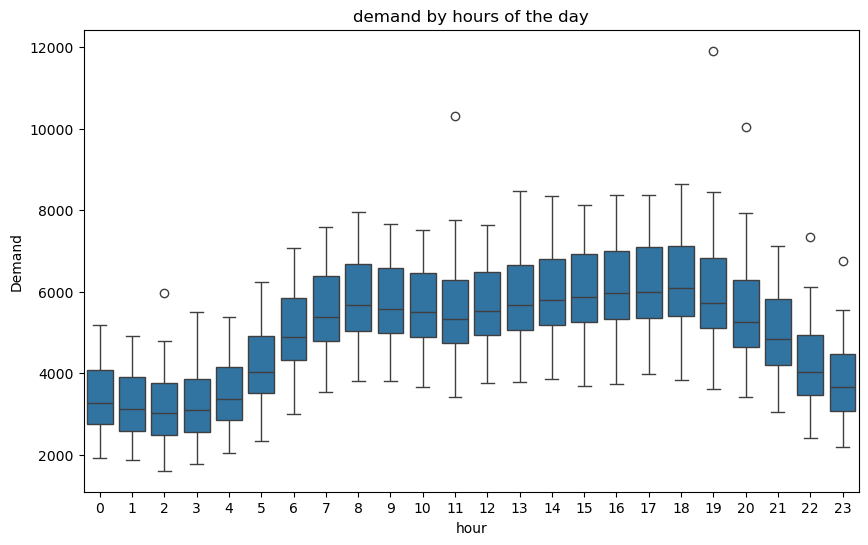

In [104]:
#visualizing the deemand in hrs of DAY 
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x ='hour' , y ='Demand')
plt.title("demand by hours of the day")
plt.show()

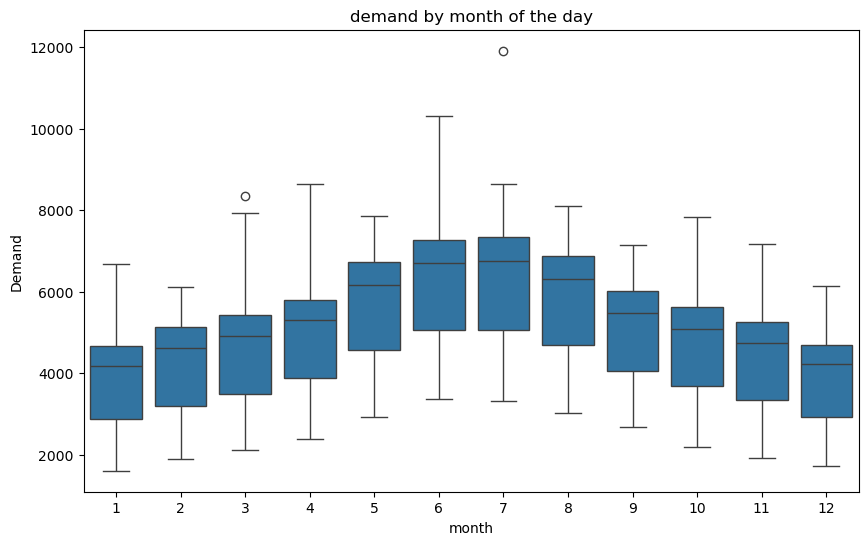

In [105]:
#visualizing the demand in months  
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x ='month' , y ='Demand')
plt.title("demand by month of the day")
plt.show()

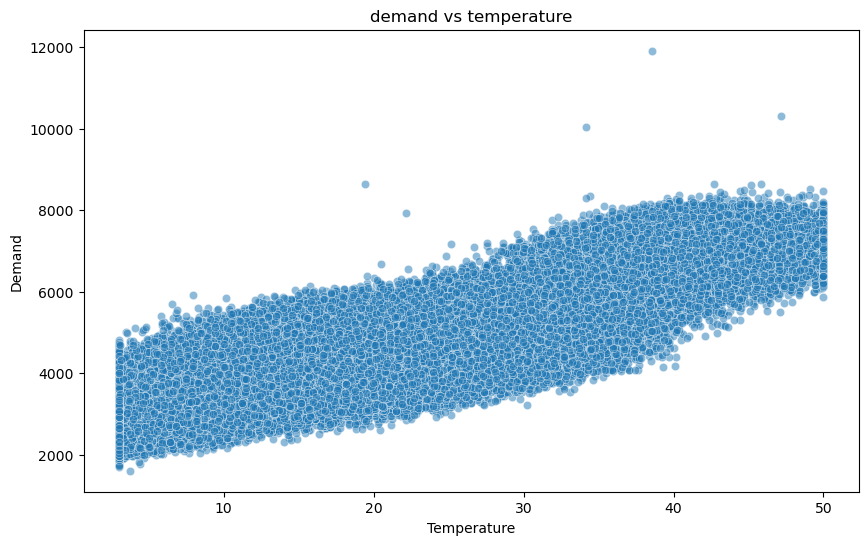

In [106]:
#visualization of demand vs temperature  
plt.figure(figsize =(10,6))
sns.scatterplot(data=df, x ='Temperature', y ='Demand', alpha =0.5)
plt.title("demand vs temperature")
plt.show()

In [107]:
#colrelation matrix 
df.corr()

,hour,dayofweek,month,year,dayofyear,weekoftheyear,quarter,is_weekends,Temperature,Humidity,Demand,Demand_lagged_24hr,Demand_lagged_168hr,Demand_rolling_mean_24hr,Demand_rolling_std_24hr
hour,1.000000,-0.000115,0.000180,0.000102,0.000171,0.000178,0.000184,-0.000209,0.051951,-0.293458,0.396163,0.396144,0.396681,0.000259,0.006961
dayofweek,-0.000115,1.000000,0.001075,-0.001110,0.001074,0.000205,0.002582,0.790556,-0.000997,-0.002241,-0.127257,-0.000106,-0.127104,-0.096528,-0.039182
month,0.000180,0.001075,1.000000,-0.008866,0.996483,0.971869,0.971288,-0.001224,-0.014012,0.597453,0.030424,0.038581,0.085690,0.055654,-0.009229
year,0.000102,-0.001110,-0.008866,1.000000,-0.009407,-0.020163,-0.007481,0.000965,-0.005114,-0.000723,0.046549,0.046322,0.046461,0.074888,-0.000619
dayofyear,0.000171,0.001074,0.996483,-0.009407,1.000000,0.973509,0.968174,-0.001039,-0.016933,0.596751,0.028220,0.036393,0.083627,0.052127,-0.012213
weekoftheyear,0.000178,0.000205,0.971869,-0.020163,0.973509,1.000000,0.947413,0.000236,-0.025676,0.596420,0.021381,0.028834,0.076439,0.040549,-0.023125
quarter,0.000184,0.002582,0.971288,-0.007481,0.968174,0.947413,1.000000,0.001131,-0.011304,0.614172,0.033023,0.041311,0.087853,0.059951,-0.004207
is_weekends,-0.000209,0.790556,-0.001224,0.000965,-0.001039,0.000236,0.001131,1.000000,-0.001066,-0.001308,-0.160283,-0.047888,-0.160137,-0.162607,-0.144626
Temperature,0.051951,-0.000997,-0.014012,-0.005114,-0.016933,-0.025676,-0.011304,-0.001066,1.000000,0.001396,0.828244,0.804325,0.796079,0.772265,0.568777
Humidity,-0.293458,-0.002241,0.597453,-0.000723,0.596751,0.596420,0.614172,-0.001308,0.001396,1.000000,-0.066283,-0.077854,-0.031615,0.069110,0.002275


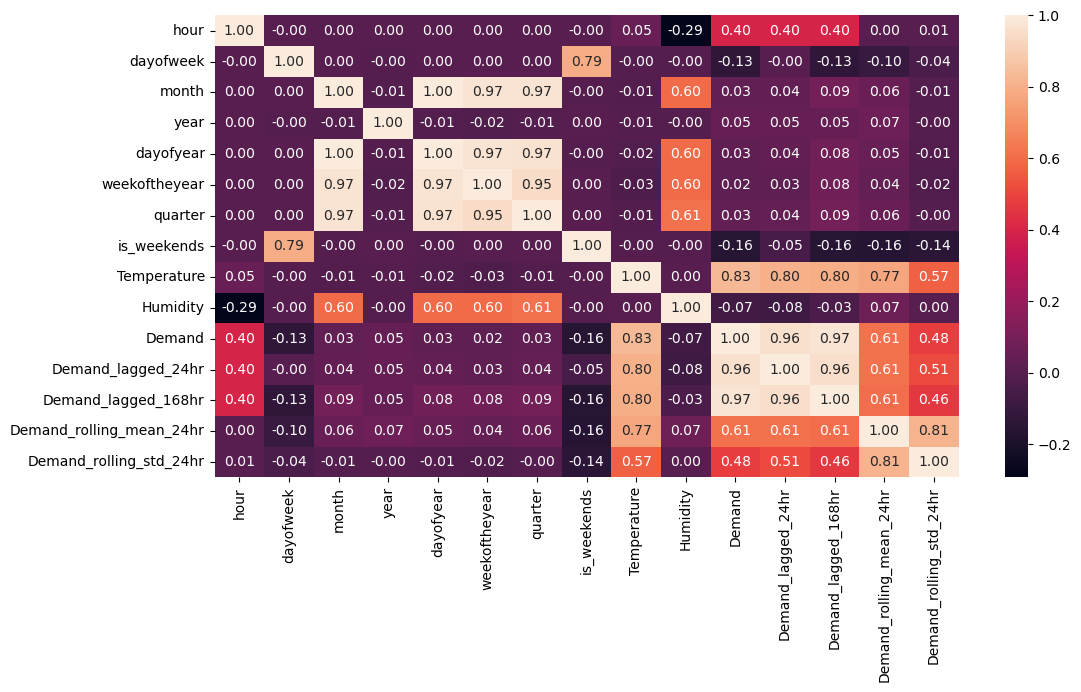

In [115]:
#heatmap 
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot =True, fmt =".2f")
plt.show()